# Heart Disease Prediction using Machine Learning

## Kularathna PKKS (IT22596352)

### Task:
- Data Loading & Preprocessing
- Logistic Regression Model Implementation
- Model Evaluation

In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# Load Dataset
df = pd.read_csv("../data/heart.csv")

# Show first 5 rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [20]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [21]:
# Convert Categorical Data to Numeric
df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [22]:
# Split Features & Target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
# Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
# Predictions
y_pred = model.predict(X_test)

In [27]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("===== Logistic Regression Results =====")
print("Accuracy:", accuracy)

===== Logistic Regression Results =====
Accuracy: 0.8532608695652174


In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[67 10]
 [17 90]]


In [29]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



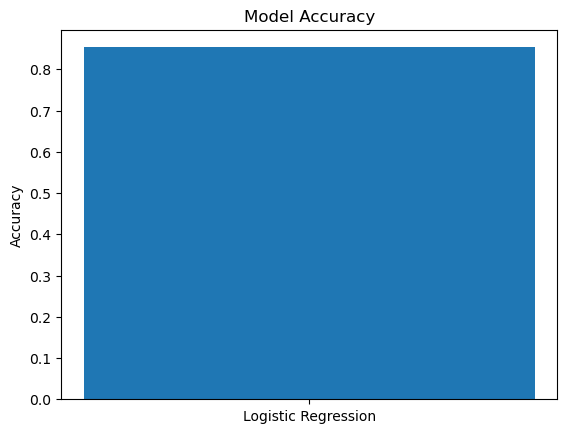

In [30]:
# Simple Accuracy Bar
plt.bar(["Logistic Regression"], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

## Model Improvement: Cross-Validation, Hyperparameter Tuning, and Threshold Optimization

This section improves the baseline Logistic Regression model using:
- Stratified cross-validation
- Hyperparameter tuning (GridSearchCV)
- Medical-focused metrics (Precision, Recall, F1, ROC-AUC)
- Decision threshold optimization

In [31]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Stratified CV keeps class proportions consistent across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline CV scores for the current logistic model
baseline_cv = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
    },
)

print("Baseline Logistic Regression (5-fold CV)")
for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    print(f"{metric}: {baseline_cv[metric].mean():.4f} (+/- {baseline_cv[metric].std():.4f})")

c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

Baseline Logistic Regression (5-fold CV)
test_accuracy: 0.8649 (+/- 0.0214)
test_precision: 0.8709 (+/- 0.0352)
test_recall: 0.8898 (+/- 0.0176)
test_f1: 0.8797 (+/- 0.0167)
test_roc_auc: 0.9247 (+/- 0.0222)


In [32]:
# Hyperparameter tuning for Logistic Regression
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",  # prioritize balance of precision/recall for disease prediction
    n_jobs=-1,
)

grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

print("Best Logistic Params:", grid_lr.best_params_)
print("Best CV F1:", round(grid_lr.best_score_, 4))

# Evaluate tuned model on test set
best_lr.fit(X_train, y_train)
y_pred_tuned = best_lr.predict(X_test)
y_proba_tuned = best_lr.predict_proba(X_test)[:, 1]

print("\nTuned Logistic Test Metrics")
print("Accuracy :", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, y_pred_tuned), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_tuned), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_tuned), 4))

Best Logistic Params: {'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.8852

Tuned Logistic Test Metrics
Accuracy : 0.8478
Precision: 0.9072
Recall   : 0.8224
F1 Score : 0.8627
ROC-AUC  : 0.9239


   threshold  precision    recall        f1
0       0.30   0.833333  0.934579  0.881057
1       0.35   0.860870  0.925234  0.891892
2       0.40   0.887850  0.887850  0.887850
3       0.45   0.894231  0.869159  0.881517
4       0.50   0.907216  0.822430  0.862745
5       0.55   0.903226  0.785047  0.840000
6       0.60   0.901099  0.766355  0.828283
7       0.65   0.915663  0.710280  0.800000
8       0.70   0.943662  0.626168  0.752809


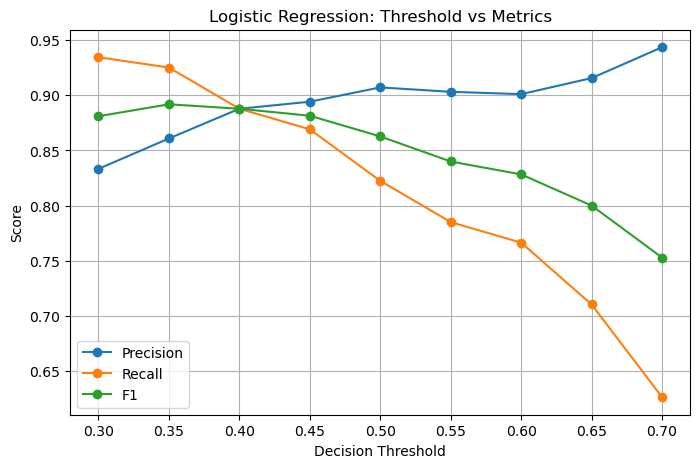

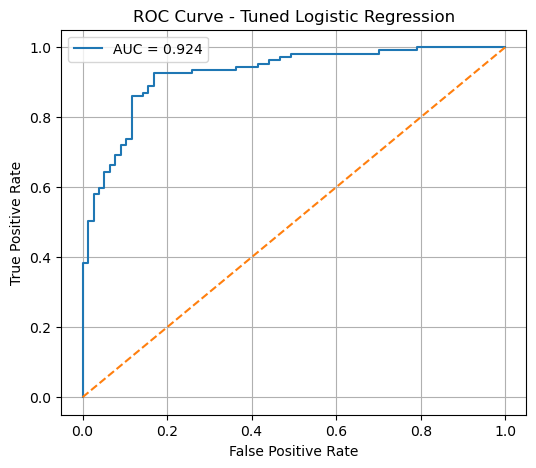

In [33]:
# Decision threshold optimization (instead of fixed 0.50)
thresholds = [i / 100 for i in range(30, 71, 5)]
threshold_results = []

for t in thresholds:
    y_pred_thr = (y_proba_tuned >= t).astype(int)
    threshold_results.append(
        {
            "threshold": t,
            "precision": precision_score(y_test, y_pred_thr),
            "recall": recall_score(y_test, y_pred_thr),
            "f1": f1_score(y_test, y_pred_thr),
        }
    )

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)

# Plot precision/recall/f1 trade-off
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression: Threshold vs Metrics")
plt.legend()
plt.grid(True)
plt.show()

# ROC curve for tuned model
fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_tuned):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Save tuned Logistic metrics for comparison notebook
import json

best_log_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_log_threshold = float(best_log_row["threshold"])

y_pred_log_best = (y_proba_tuned >= best_log_threshold).astype(int)

logistic_metrics = {
    "model": "Logistic Regression",
    "threshold": round(best_log_threshold, 4),
    "accuracy": round(float(accuracy_score(y_test, y_pred_log_best)), 4),
    "precision": round(float(precision_score(y_test, y_pred_log_best)), 4),
    "recall": round(float(recall_score(y_test, y_pred_log_best)), 4),
    "f1": round(float(f1_score(y_test, y_pred_log_best)), 4),
    "auc": round(float(roc_auc_score(y_test, y_proba_tuned)), 4),
}

with open("../comparison/logistic.json", "w") as f:
    json.dump(logistic_metrics, f, indent=2)

print("Saved ../comparison/logistic.json")
logistic_metrics

Saved ../comparison/logistic.json


{'model': 'Logistic Regression',
 'threshold': 0.35,
 'accuracy': 0.8696,
 'precision': 0.8609,
 'recall': 0.9252,
 'f1': 0.8919,
 'auc': 0.9239}